# Appendix: Empirical Analysis - Monroe et al. (2022)

In [40]:
import os
from pathlib import Path
import re, warnings, json, random

import pandas as pd
import numpy as np

import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scipy.stats import skew, kurtosis, spearmanr

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
from IPython.display import display
from matplotlib.transforms import blended_transform_factory


### Figure 1 - Top Predictors

chrom column not found; falling back to HC3 robust SEs.
Top rigor predictors (K=5): ['H3K4me1', 'H3K4me3', 'H3K36ac', 'GC_content_pct', 'CG_pct']

Mean model (OLS on rigor set) — effects and q-values:


,beta,p,q
predictor,,,
H3K4me1,-1.98e-06,1.84e-09,9.19e-09
H3K4me3,-9.99e-07,0.000579,0.00108
H3K36ac,-5.74e-07,0.000646,0.00108
GC_content_pct,2.24e-07,0.223,0.278
CG_pct,-1.24e-07,0.409,0.409


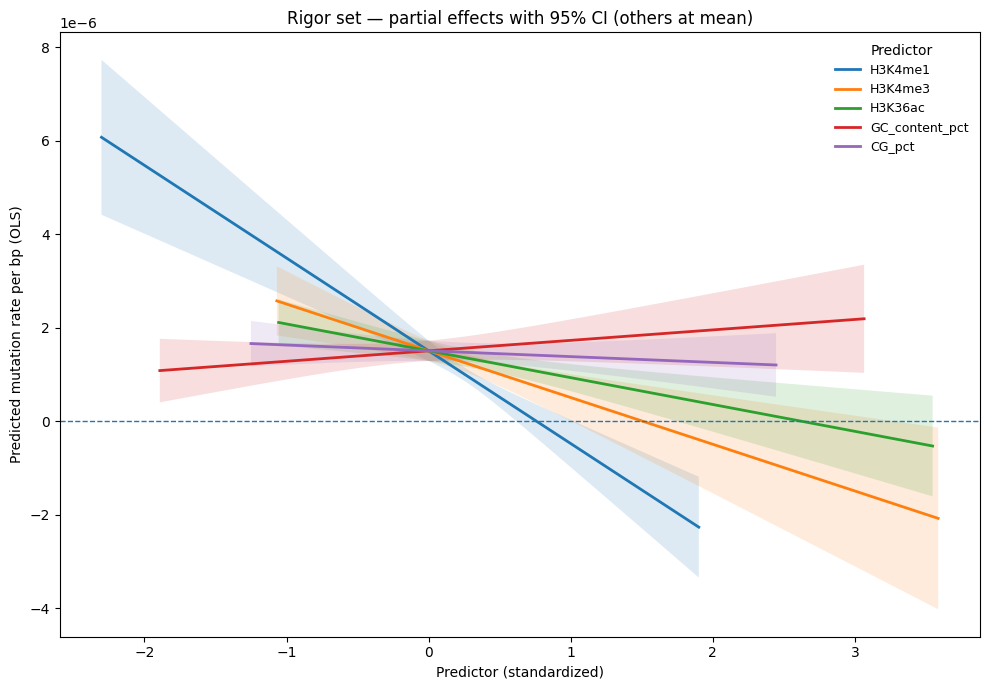

In [ ]:
DATA_PATH = Path("/Users/elisaheinrichmora/Documents/GitHub/Random_Modifier/Data/gene_level_data.csv")
OUT_DIR   = Path("/Users/elisaheinrichmora/Documents/GitHub/Random_Modifier/Figures"); OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_PATH  = OUT_DIR / "af1_reg_lines_mutations.png"
PREDICTORS = [
    "atac_pct", "GC_content_pct", "CHG_pct", "CHH_pct", "CG_pct",
    "H3K9me2", "H3K9me1", "H3K9ac", "H3K56ac",
    "H3K4me3", "H3K4me2", "H3K4me1",
    "H3K36me3", "H3K36ac",
    "H3K27me1", "H3K27ac", "H3K23ac", "H3K14ac",
]

TOP_K       = 5
VIF_THRESH  = 10.0       # maybe 5.0 if you want stricter collinearity control
USE_CLUSTER_BY_CHROM = True   # cluster-robust SEs by chromosome if 'chrom' column exists
EPS = 1e-9
np.random.seed(42)
pd.options.display.float_format = "{:,.3g}".format


# Helpers -----------------------------------
def bh_fdr(pvals):
    """
    Benjamini–Hochberg FDR correction.
    - Input: list/array of p-values.
    - Replaces NaNs with 1 (conservative).
    - Returns: array of q-values.
    """
    p = np.asarray(pvals, float)
    p = np.where(np.isfinite(p), p, 1.0)  # conservative
    return multipletests(p, method="fdr_bh")[1]


def safe_zscore(X: pd.DataFrame) -> pd.DataFrame:
    """
    Standardize predictors (mean=0, std=1).
    - Drops columns that are constant or non-finite.
    - Prevents divide-by-zero issues.
    """
    X = X.copy()
    s = X.std(ddof=0)
    bad = s[(~np.isfinite(s)) | (s==0)].index.tolist()
    if bad: X = X.drop(columns=bad)
    mu, s = X.mean(), X.std(ddof=0).replace(0, np.nan)
    return (X - mu) / s

def compute_vif_table(X: pd.DataFrame) -> pd.DataFrame:
    """
    Compute Variance Inflation Factor (VIF) for each predictor.
    - Adds constant, regresses each predictor against all others.
    - Higher VIF = more collinearity.
    - Returns table of predictors and their VIF values.
    """
    Xc = sm.add_constant(X, has_constant="add"); rows = []
    for i, col in enumerate(Xc.columns):
        if col == "const": continue
        try:  v = float(variance_inflation_factor(Xc.values, i))
        except Exception: v = np.nan
        rows.append((col, v))
    return pd.DataFrame(rows, columns=["predictor","VIF"]).sort_values("VIF", ascending=False)

def vif_prune(X: pd.DataFrame, thresh=10.0):
    """
    Iteratively prune predictors with highest VIF above threshold.
    - Removes worst offender until all VIF ≤ threshold.
    - Returns pruned DataFrame + list of dropped predictors.
    """
    Xp, dropped = X.copy(), []
    while Xp.shape[1] > 1:
        vtab = compute_vif_table(Xp); worst = vtab.iloc[0]
        if np.isfinite(worst["VIF"]) and worst["VIF"] <= thresh: break
        Xp = Xp.drop(columns=[worst["predictor"]])
        dropped.append((worst["predictor"], float(worst["VIF"]) if np.isfinite(worst["VIF"]) else None))
    return Xp, dropped

def _norm(s: str) -> str:
    """
    Normalize header strings for robust matching across spelling/spacing variants.
    """
    s = str(s).strip().lower().replace("_", " ")
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^a-z0-9 ]+", "", s)
    return s.replace(" ", "")

def resolve_col(df: pd.DataFrame, candidates):
    """
    Return the original df column that matches any candidate after normalization.
    """
    col_map = {_norm(c): c for c in df.columns}
    for cand in candidates:
        key = _norm(cand)
        if key in col_map:
            return col_map[key]
    return None

def show_top(df_, cols, k=10, title=""):
    print(f"\n{title}")
    display(df_[cols].sort_values(cols[-1]).head(k))


def sign(x): 
    try: return "−" if float(x) < 0 else "+"
    except: return "?"

# Data -----------------------------------
df = pd.read_csv(DATA_PATH)

# Subset ESN/lethal 
mask_parts = []
if "lethal" in df.columns: mask_parts.append(df["lethal"].astype(str).str.lower().eq("lethal"))
if "essentiality" in df.columns: mask_parts.append(df["essentiality"].astype(str).str.upper().eq("ESN"))
if mask_parts:
    m = mask_parts[0]
    for mm in mask_parts[1:]: m = m | mm
    df = df[m].copy()

# Mutation rate per bp
mut_col, len_col = "Mutations", "CDS length"

# Remove zero/near-zero lengths (unstable rates/weights)
df = df[df[len_col].astype(float) > 0].copy()


# Rescale *_pct to [0,1] if they look like percentages
rescaled = []
for c in [c for c in PREDICTORS if c in df.columns and c.endswith("_pct")]:
    med = np.nanmedian(df[c].astype(float))
    if 1.0 < med <= 100.0:
        df[c] = df[c].astype(float)/100.0
        rescaled.append(c)
if rescaled:
    print("Rescaled to 0–1:", rescaled)

# Mutation rate per bp
df["mut_rate_per_bp"] = df[mut_col].astype(float)/(df[len_col].astype(float)+EPS)

present = [c for c in PREDICTORS if c in df.columns]
if not present: raise ValueError("None of the requested predictors are present.")
df = df.dropna(subset=present + ["mut_rate_per_bp", mut_col, len_col]).copy()

# Covariance settings
if USE_CLUSTER_BY_CHROM and "chrom" in df.columns:
    cov_kw = dict(cov_type="cluster", cov_kwds={"groups": df["chrom"]})
    print("Using cluster-robust SEs by chromosome.")
else:
    cov_kw = dict(cov_type="HC3")
    if USE_CLUSTER_BY_CHROM:
        print("chrom column not found; falling back to HC3 robust SEs.")

# Predictors -----------------------------------
y = df["mut_rate_per_bp"].values
X0 = df[present].astype(float)

# VIF pruning (on raw scale; VIF is scale-invariant)
X_vif_all, dropped_vif_all = vif_prune(X0, VIF_THRESH)
Xs_all = safe_zscore(X_vif_all)
X_ols_all = sm.add_constant(Xs_all, has_constant="add")

# OLS 
ols_all = sm.OLS(y, X_ols_all).fit(**cov_kw)
ols_tab = pd.DataFrame({
    "predictor": Xs_all.columns,
    "p": [float(ols_all.pvalues[p]) for p in Xs_all.columns]
})
ols_tab["q"] = bh_fdr(ols_tab["p"])

# WLS (length weights)
wls_all = sm.WLS(y, X_ols_all, weights=df[len_col].astype(float).values).fit(**cov_kw)
wls_tab = pd.DataFrame({
    "predictor": Xs_all.columns,
    "p": [float(wls_all.pvalues[p]) for p in Xs_all.columns]
})
wls_tab["q"] = bh_fdr(wls_tab["p"])

# Poisson GLM with log-length offset (counts on log-rate scale)
glm_tab = None
try:
    y_counts = df[mut_col].astype(int).values
    glm = sm.GLM(y_counts, X_ols_all, family=sm.families.Poisson(),
                 offset=np.log(df[len_col].astype(float)))
    glm_res = glm.fit(**cov_kw)
    glm_tab = pd.DataFrame({
        "predictor": Xs_all.columns,
        "p": [float(glm_res.pvalues[p]) for p in Xs_all.columns]
    })
    glm_tab["q"] = bh_fdr(glm_tab["p"])
except Exception as e:
    warnings.warn(f"GLM Poisson with offset failed; excluding from rigor rank. ({e})")

# Average FDR rank across available multivariable models (OLS, WLS, +GLM if available)
rank = pd.DataFrame({"predictor": Xs_all.columns}).set_index("predictor")
rank["r_ols"] = ols_tab.set_index("predictor")["q"].rank(method="min")
rank["r_wls"] = wls_tab.set_index("predictor")["q"].rank(method="min")
if glm_tab is not None:
    rank["r_glm"] = glm_tab.set_index("predictor")["q"].rank(method="min")
    rank["r_rigor_mean"] = rank[["r_ols","r_wls","r_glm"]].mean(axis=1)
else:
    rank["r_rigor_mean"] = rank[["r_ols","r_wls"]].mean(axis=1)

top_preds_rigor = rank.sort_values("r_rigor_mean").head(min(TOP_K, len(rank))).index.tolist()

print(f"Top rigor predictors (K={len(top_preds_rigor)}): {top_preds_rigor}")

# Model -----------------------------------
X_top = df[top_preds_rigor].astype(float)
X_top_vif, dropped_vif_top = vif_prune(X_top, VIF_THRESH)
if dropped_vif_top:
    print("Dropped within-top due to VIF>threshold:", dropped_vif_top)
    # shrink the rigor set accordingly
    top_preds_rigor = [c for c in top_preds_rigor if c in X_top_vif.columns]

Xs_rigor = safe_zscore(X_top_vif)
X_ols_rigor = sm.add_constant(Xs_rigor, has_constant="add")
ols_rigor = sm.OLS(y, X_ols_rigor).fit(**cov_kw)

# Summaries -----------------------------------
res_table = pd.DataFrame({
    "predictor": Xs_rigor.columns,
    "beta": [float(ols_rigor.params[p]) for p in Xs_rigor.columns],
    "p":    [float(ols_rigor.pvalues[p]) for p in Xs_rigor.columns]
}).set_index("predictor")
res_table["q"] = bh_fdr(res_table["p"])
print("\nMean model (OLS on rigor set) — effects and q-values:")
display(res_table.sort_values("q"))

# Plots -----------------------------------
plt.figure(figsize=(10, 7))
coef_cols = ["const"] + list(Xs_rigor.columns)
for pred in top_preds_rigor:
    if pred not in Xs_rigor.columns: 
        continue
    xvals = Xs_rigor[pred].to_numpy()
    lo, hi = float(np.nanpercentile(xvals, 1)), float(np.nanpercentile(xvals, 99))
    x_grid = np.linspace(lo, hi, 200)
    Xgrid = pd.DataFrame(0.0, index=range(len(x_grid)), columns=coef_cols)
    Xgrid["const"] = 1.0
    Xgrid[pred] = x_grid
    pred_res = ols_rigor.get_prediction(Xgrid)
    mean = pred_res.predicted_mean
    ci_l, ci_u = pred_res.conf_int().T
    plt.plot(x_grid, mean, linewidth=2, label=pred)
    plt.fill_between(x_grid, ci_l, ci_u, alpha=0.15)

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Predictor (standardized)"); plt.ylabel("Predicted mutation rate per bp (OLS)")
plt.title("Rigor set — partial effects with 95% CI (others at mean)")
plt.legend(title="Predictor", frameon=False, fontsize=9)
plt.tight_layout(); plt.savefig(FIG_PATH, dpi=300, format="png")
plt.show()


# Keep in memory for the moments heatmap
MOMENTS_STATE = {
    "df": df, "y": y, "len_col": len_col,
    "Xs_rigor": Xs_rigor, "X_ols_rigor": X_ols_rigor, "ols_rigor": ols_rigor,
    "top_preds_rigor": top_preds_rigor, "cov_kw": cov_kw
}

### Figure 2 - Predictors and Moments


Rigor set — summary across moments (effects and FDR q-values):


,mean_beta,mean_q,var_pct_perSD,var_q,skew_coef,skew_q,kurt_coef,kurt_q
H3K4me1,-1.98e-06,9.19e-09,-84.9,4.04e-95,13.5,0.897,161,0.824
H3K4me3,-9.99e-07,0.00108,-58.9,1.05e-36,9.85,0.897,188,0.824
H3K36ac,-5.74e-07,0.00108,-36.2,4.94e-14,8.21,0.897,96.9,0.824
GC_content_pct,2.24e-07,0.278,38.7,1.3e-12,-1.67,0.918,-62.4,0.824
CG_pct,-1.24e-07,0.409,-18.2,4.95e-06,-6.9,0.897,-124,0.824


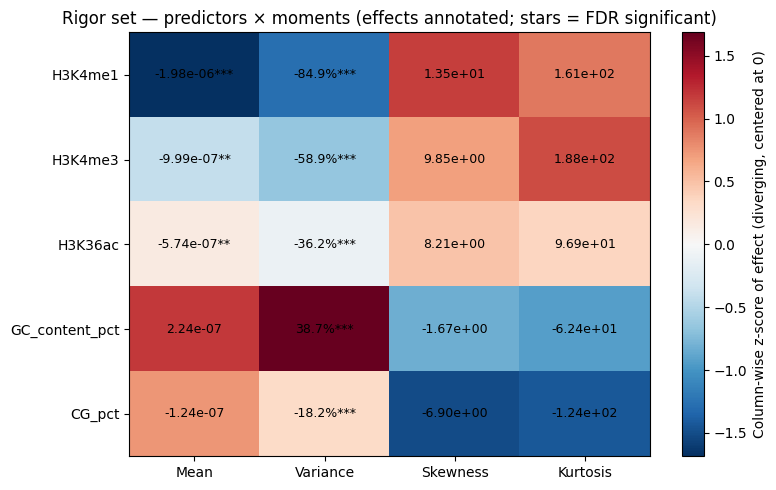

In [ ]:
try:
    state = MOMENTS_STATE
except NameError:
    raise RuntimeError("Cell 1 has not been run. Please run Cell 1 first to define the rigor set.")

# Unpack state
df           = state["df"]
y            = state["y"]
len_col      = state["len_col"]
Xs_rigor     = state["Xs_rigor"]
X_ols_rigor  = state["X_ols_rigor"]
ols_rigor    = state["ols_rigor"]
top_preds    = state["top_preds_rigor"]
cov_kw       = state["cov_kw"]

# Params
CLIP_Q = (0.5, 99.5)


#  Helpers -----------------------------------
def bh_fdr(p):
    p = np.asarray(p, float)
    p = np.where(np.isfinite(p), p, 1.0)
    return multipletests(p, method="fdr_bh")[1]

def star_from_q(q):
    if pd.isna(q): return ""
    if q < 1e-3:  return "***"
    if q < 1e-2:  return "**"
    if q < 5e-2:  return "*"
    return ""


# Models -----------------------------------

# Mean -----------------------------------
mean_tab = pd.DataFrame({
    "predictor": Xs_rigor.columns,
    "beta": [float(ols_rigor.params[p]) for p in Xs_rigor.columns],
    "p":    [float(ols_rigor.pvalues[p]) for p in Xs_rigor.columns]
}).set_index("predictor")
mean_tab["q"] = bh_fdr(mean_tab["p"])

#  Variance model: log(resid^2) -----------------------------------
r = y - ols_rigor.fittedvalues
z_var = np.log(r**2 + 1e-30)
ols_var = sm.OLS(z_var, X_ols_rigor).fit(**cov_kw)
var_tab = pd.DataFrame({
    "predictor": Xs_rigor.columns,
    "gamma": [float(ols_var.params[p]) for p in Xs_rigor.columns],
    "se":    [float(ols_var.bse[p])    for p in Xs_rigor.columns],
    "p":     [float(ols_var.pvalues[p]) for p in Xs_rigor.columns]
}).set_index("predictor")
var_tab["q"] = bh_fdr(var_tab["p"])
var_tab["pct_var_perSD"] = 100*(np.exp(var_tab["gamma"]) - 1.0)

# Variance-standardized residuals
sigma2_hat = np.exp(ols_var.fittedvalues)
u = r / np.sqrt(sigma2_hat + 1e-30)
qlo, qhi = np.nanpercentile(u, CLIP_Q)
u_c = np.clip(u, qlo, qhi)

# Skewness model: u^3 -----------------------------------
z_skew = u_c**3
ols_skew = sm.OLS(z_skew, X_ols_rigor).fit(**cov_kw)
skew_tab = pd.DataFrame({
    "predictor": Xs_rigor.columns,
    "coef": [float(ols_skew.params[p]) for p in Xs_rigor.columns],
    "p":    [float(ols_skew.pvalues[p]) for p in Xs_rigor.columns]
}).set_index("predictor")
skew_tab["q"] = bh_fdr(skew_tab["p"])

#  Kurtosis model: u^4 - 3 -----------------------------------
z_kurt = u_c**4 - 3.0
ols_kurt = sm.OLS(z_kurt, X_ols_rigor).fit(**cov_kw)
kurt_tab = pd.DataFrame({
    "predictor": Xs_rigor.columns,
    "coef": [float(ols_kurt.params[p]) for p in Xs_rigor.columns],
    "p":    [float(ols_kurt.pvalues[p]) for p in Xs_rigor.columns]
}).set_index("predictor")
kurt_tab["q"] = bh_fdr(kurt_tab["p"])



# Summaries -----------------------------------
preds = [p for p in top_preds if p in Xs_rigor.columns]  # guard if any dropped by VIF
summary = pd.DataFrame(index=preds)
summary["mean_beta"]     = mean_tab.loc[preds, "beta"]
summary["mean_q"]        = mean_tab.loc[preds, "q"]
summary["var_pct_perSD"] = var_tab.loc[preds, "pct_var_perSD"]
summary["var_q"]         = var_tab.loc[preds, "q"]
summary["skew_coef"]     = skew_tab.loc[preds, "coef"]
summary["skew_q"]        = skew_tab.loc[preds, "q"]
summary["kurt_coef"]     = kurt_tab.loc[preds, "coef"]
summary["kurt_q"]        = kurt_tab.loc[preds, "q"]

print("\nRigor set — summary across moments (effects and FDR q-values):")
display(summary)

# Plots -----------------------------------
# Effects matrix for display
effects = summary.rename(columns={
    "mean_beta":"Mean",
    "var_pct_perSD":"Variance",
    "skew_coef":"Skewness",
    "kurt_coef":"Kurtosis"
})[["Mean","Variance","Skewness","Kurtosis"]]

# Stars from per-panel BH
stars = pd.DataFrame({
    "Mean":     summary["mean_q"].map(star_from_q),
    "Variance": summary["var_q"].map(star_from_q),
    "Skewness": summary["skew_q"].map(star_from_q),
    "Kurtosis": summary["kurt_q"].map(star_from_q),
}, index=effects.index)

# Column-wise z-score for coloring ONLY
col_z = effects.copy().astype(float)
for c in col_z.columns:
    v = col_z[c].to_numpy()
    mu, sd = np.nanmean(v), np.nanstd(v)
    col_z[c] = (col_z[c] - mu) / (sd if sd > 0 else 1.0)

vlim = np.nanpercentile(np.abs(col_z.to_numpy()), 95)
if not np.isfinite(vlim) or vlim <= 0:
    vlim = np.nanmax(np.abs(col_z.to_numpy()))
norm = TwoSlopeNorm(vmin=-vlim, vcenter=0.0, vmax=vlim)

fig, ax = plt.subplots(figsize=(8, 0.6*len(preds)+2))
im = ax.imshow(col_z.to_numpy(), aspect="auto", norm=norm, cmap="RdBu_r")
ax.set_yticks(range(len(preds))); ax.set_yticklabels(effects.index.tolist())
ax.set_xticks(range(effects.shape[1])); ax.set_xticklabels(effects.columns.tolist())

# Annotate with raw values + stars (Variance shown in %, others in scientific notation)
for i in range(effects.shape[0]):
    for j in range(effects.shape[1]):
        val = effects.iat[i,j]
        st  = stars.iat[i,j]
        if effects.columns[j] == "Variance":
            txt = f"{val:,.1f}%{st}" if np.isfinite(val) else ""
        else:
            txt = f"{val:.2e}{st}" if np.isfinite(val) else ""
        ax.text(j, i, txt, ha="center", va="center", fontsize=9, color="black")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Column-wise z-score of effect (diverging, centered at 0)")
ax.set_title("Rigor set — predictors × moments (effects annotated; stars = FDR significant)")
plt.tight_layout()
plt.savefig( OUT_DIR / "af2_predictors_moments.png", dpi=300, format="png")
plt.show()

### Figure 3: Tajima's D 

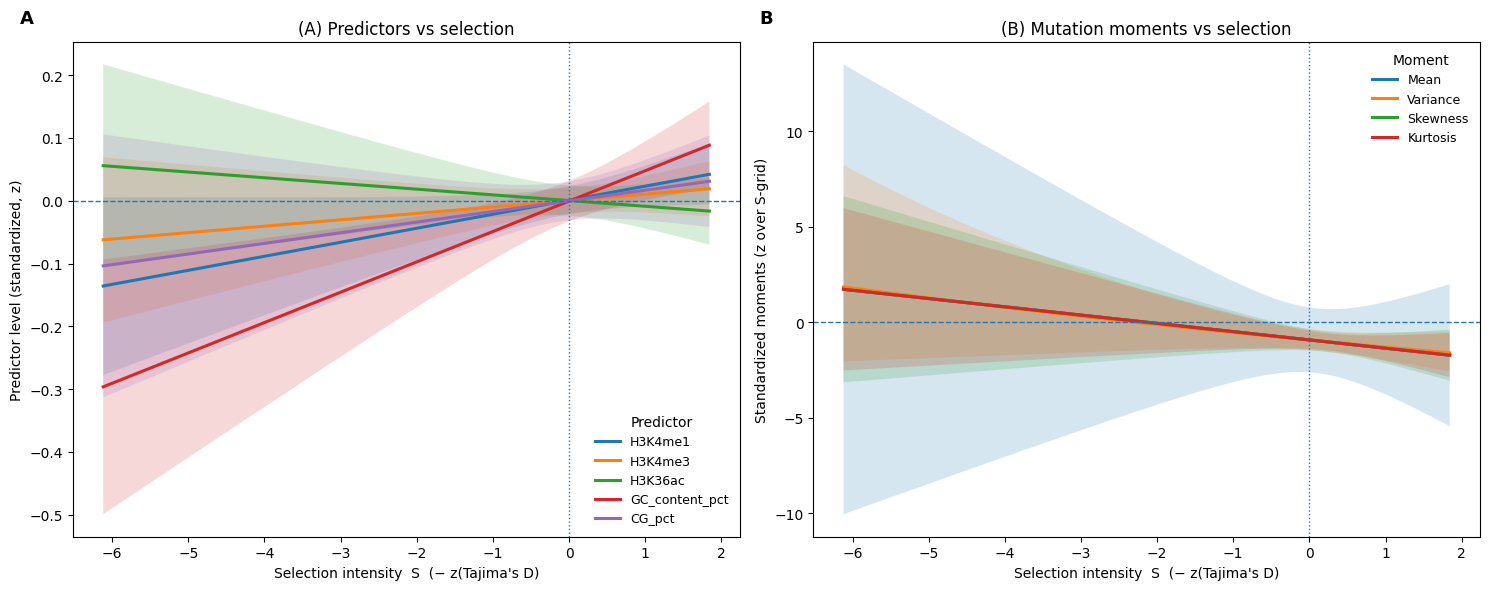


Selection intensity S effects (partial, robust; +1 SD in S = stronger selection):


,Effect per +1 SD in S,FDR q-value
Mean (level),-5.560e-08,0.652
Variance (%Δ),-5.2%,0.185
Skewness,-1.374e+01,0.266
Kurtosis,-2.764e+02,0.201



Predictors vs selection (partial): slope = SD(predictor) change per +1 SD in S; robust 95% CI; BH-FDR across predictors


,predictor,slope_SD_per_SD_S,ci_lo,ci_hi,p,rho_spearman,q
0,GC_content_pct,0.0483,0.0154,0.0812,0.00397,0.0444,0.0199
1,H3K4me1,0.0223,-0.000654,0.0453,0.0569,0.0303,0.142
2,CG_pct,0.0169,-0.0174,0.0512,0.334,0.0329,0.432
3,H3K4me3,0.0102,-0.011,0.0314,0.346,-0.0144,0.432
4,H3K36ac,-0.00909,-0.0351,0.017,0.494,-0.035,0.494



Top 5 predictors by FDR q (lower is stronger evidence):


,predictor,slope_SD_per_SD_S,ci_lo,ci_hi,p,q,rho_spearman
0,GC_content_pct,0.0483,0.0154,0.0812,0.00397,0.0199,0.0444
1,H3K4me1,0.0223,-0.000654,0.0453,0.0569,0.142,0.0303
2,CG_pct,0.0169,-0.0174,0.0512,0.334,0.432,0.0329
3,H3K4me3,0.0102,-0.011,0.0314,0.346,0.432,-0.0144
4,H3K36ac,-0.00909,-0.0351,0.017,0.494,0.494,-0.035


In [48]:
STANDARDIZE_MOMENTS_FOR_PLOT = True   # plot moments as z-scores across S-grid (unitless, centered 0)
SHOW_BINS = True                      # show S-binned raw means ± SEM for predictors in Panel A
N_BINS_FOR_PREDICTORS = 10
ALPHA_RIBBON = 0.18
LINEWIDTH = 2.2
EPS = 1e-30


# Helpers -----------------------------------
def bh_fdr(p):
    p = np.asarray(p, float); p = np.where(np.isfinite(p), p, 1.0)
    return multipletests(p, method="fdr_bh")[1]

def _norm(s: str) -> str:
    s = str(s).strip().lower().replace("_", " "); s = re.sub(r"\s+", " ", s); s = re.sub(r"[^a-z0-9 ]+", "", s)
    return s.replace(" ", "")

def resolve_col(df: pd.DataFrame, candidates):
    col_map = {_norm(c): c for c in df.columns}
    for cand in candidates:
        key = _norm(cand)
        if key in col_map: return col_map[key]
    return None

def design_on_S(s_vals, cols):
    M = pd.DataFrame(0.0, index=range(len(s_vals)), columns=["const"] + cols.tolist())
    M["const"] = 1.0
    M["SelectionIntensity_z"] = s_vals
    return M

def zscore_family(mean_curve, lo_curve, hi_curve):
    """
    Standardize CI band consistently using μ,σ of the mean curve.
    """
    mean_curve = np.asarray(mean_curve, float)
    lo_curve   = np.asarray(lo_curve, float)
    hi_curve   = np.asarray(hi_curve, float)
    mu = np.nanmean(mean_curve)
    sd = np.nanstd(mean_curve)
    if not np.isfinite(sd) or sd <= 0:
        sd = 1.0
    return (mean_curve - mu)/sd, (lo_curve - mu)/sd, (hi_curve - mu)/sd


# Data -----------------------------------
try:
    state = MOMENTS_STATE
except NameError:
    raise RuntimeError("Please run Cell 1 first to define MOMENTS_STATE.")

df           = state["df"].copy()
len_col      = state["len_col"]
Xs_rigor     = state["Xs_rigor"]           # standardized rigor predictors (columns = top rigor set)
cov_kw       = state["cov_kw"]

if "mut_rate_per_bp" not in df.columns:
    raise ValueError("Column 'mut_rate_per_bp' not found in df (did Cell 1 run?).")


# Selection intensity S = - z(Tajima's D) -----------------------------------
taj_col = resolve_col(df, ["Tajima's D","Tajimas D","TajimaD","tajima d","tajima_d","tajd","tajimas_d","tajimasd"])
if taj_col is None:
    raise ValueError(f"Tajima's D column not found. Available columns: {list(df.columns)}")

# Common analysis index: require TajD, outcome, length, and rigor predictors
needed = list(Xs_rigor.columns) + [taj_col, "mut_rate_per_bp", len_col]
idx = df[needed].dropna().index
if len(idx) < 50:
    warnings.warn(f"Low sample size for selection analysis after NA drop (n={len(idx)}).")

taj = df.loc[idx, taj_col].astype(float)
sd_taj = taj.std(ddof=0)
if not np.isfinite(sd_taj) or sd_taj == 0:
    raise ValueError("Tajima's D has zero/non-finite variance; cannot standardize.")
S = -(taj - taj.mean())/sd_taj
S.name = "SelectionIntensity_z"

# Align design and outcome
Xr = Xs_rigor.loc[idx].copy()                         # standardized predictors (z)
y  = df.loc[idx, "mut_rate_per_bp"].astype(float).values

# --------------------------------------------------------------------------------
# (A) Predictors vs Selection: -----------------------------------
# --------------------------------------------------------------------------------
# For each predictor p, fit partial regression: X_p ~ S + X_{-p}; robust covariance.
pred_fits = {}
for p in Xr.columns:
    X_rhs = pd.concat([S.rename("SelectionIntensity_z"), Xr.drop(columns=p)], axis=1)
    X_rhs = sm.add_constant(X_rhs, has_constant="add")
    fit = sm.OLS(Xr[p].values, X_rhs).fit(**cov_kw)
    pred_fits[p] = fit

s_min, s_max = float(S.min()), float(S.max())
s_grid = np.linspace(s_min, s_max, 200)

curves_A = {}
bands_A  = {}
for p, fit in pred_fits.items():
    # For adjusted curve set other predictors at 0, vary S along grid
    Xnew = pd.DataFrame(0.0, index=range(len(s_grid)), columns=fit.params.index)
    Xnew["const"] = 1.0
    Xnew["SelectionIntensity_z"] = s_grid
    sf = fit.get_prediction(Xnew).summary_frame(alpha=0.05)   # robust CI from cov_kw
    curves_A[p] = sf["mean"].to_numpy()
    bands_A[p]  = (sf["mean_ci_lower"].to_numpy(), sf["mean_ci_upper"].to_numpy())

# Binned raw means ± SEM (descriptive)
if SHOW_BINS:
    bins = pd.qcut(S, q=N_BINS_FOR_PREDICTORS, duplicates="drop")
    s_bin = S.groupby(bins).mean().to_numpy()
    raw_binned, raw_sem = {}, {}
    for p in Xr.columns:
        g = Xr[p].groupby(bins)
        raw_binned[p] = g.mean().to_numpy()
        cnt = g.size().to_numpy().astype(float)
        sd  = g.std(ddof=1).to_numpy()
        with np.errstate(divide='ignore', invalid='ignore'):
            raw_sem[p] = np.where(cnt > 1, sd/np.sqrt(cnt), np.nan)

# --------------------------------------------------------------------------------
# (B) Moments vs Selection -----------------------------------
# --------------------------------------------------------------------------------
# Extended designs include S additively with rigor predictors
X_ext = pd.concat([Xr, S], axis=1)
X_ext_ols = sm.add_constant(X_ext, has_constant="add")

# Mean model
ols_mean = sm.OLS(y, X_ext_ols).fit(**cov_kw)

# Variance model (Harvey/White): log(resid^2) ~ X + S
resid = y - ols_mean.fittedvalues
z_var = np.log(resid**2 + 1e-30)
ols_var = sm.OLS(z_var, X_ext_ols).fit(**cov_kw)

# Variance-standardize residuals for skew/kurt
sigma2_hat = np.exp(ols_var.fittedvalues)
u = resid / np.sqrt(sigma2_hat + 1e-30)
# Clip to stabilize higher moments (as in Cell 2)
qlo, qhi = np.nanpercentile(u, [0.5, 99.5]); u_c = np.clip(u, qlo, qhi)
u_c = np.clip(u, qlo, qhi)

# Skewness and kurtosis models
z_skew = u_c**3
ols_skew = sm.OLS(z_skew, X_ext_ols).fit(**cov_kw)

z_kurt = u_c**4 - 3.0
ols_kurt = sm.OLS(z_kurt, X_ext_ols).fit(**cov_kw)

# Prediction design along S with predictors at 0
cols_ext = X_ext.columns
M_grid = design_on_S(s_grid, cols_ext)

# Mean predictions (level)
sf_mean = ols_mean.get_prediction(M_grid).summary_frame(alpha=0.05)
mean_line = sf_mean["mean"].to_numpy()
mean_lo   = sf_mean["mean_ci_lower"].to_numpy()
mean_hi   = sf_mean["mean_ci_upper"].to_numpy()


# Variance predictions: transform to % change relative to S=0
sf_var = ols_var.get_prediction(M_grid).summary_frame(alpha=0.05)
var_log    = sf_var["mean"].to_numpy()
var_lo_log = sf_var["mean_ci_lower"].to_numpy()
var_hi_log = sf_var["mean_ci_upper"].to_numpy()

M0 = design_on_S(np.array([0.0]), cols_ext)
base_logvar = float(ols_var.get_prediction(M0).predicted_mean)
var_line = 100*(np.exp(var_log    - base_logvar) - 1.0)
var_lo   = 100*(np.exp(var_lo_log - base_logvar) - 1.0)
var_hi   = 100*(np.exp(var_hi_log - base_logvar) - 1.0)


# Skewness predictions
sf_skew = ols_skew.get_prediction(M_grid).summary_frame(alpha=0.05)
skew_line = sf_skew["mean"].to_numpy()
skew_lo   = sf_skew["mean_ci_lower"].to_numpy()
skew_hi   = sf_skew["mean_ci_upper"].to_numpy()

# Kurtosis predictions
sf_kurt = ols_kurt.get_prediction(M_grid).summary_frame(alpha=0.05)
kurt_line = sf_kurt["mean"].to_numpy()
kurt_lo   = sf_kurt["mean_ci_lower"].to_numpy()
kurt_hi   = sf_kurt["mean_ci_upper"].to_numpy()


# Optional: standardize curves for plotting comparability (z over s_grid)
if STANDARDIZE_MOMENTS_FOR_PLOT:
    mean_plot, mean_lo_p, mean_hi_p = zscore_family(mean_line, mean_lo, mean_hi)
    var_plot,  var_lo_p,  var_hi_p  = zscore_family(var_line,  var_lo,  var_hi)
    skew_plot, skew_lo_p, skew_hi_p = zscore_family(skew_line, skew_lo, skew_hi)
    kurt_plot, kurt_lo_p, kurt_hi_p = zscore_family(kurt_line, kurt_lo, kurt_hi)
    ylab_B = "Standardized moments (z over S-grid)"
else:
    SCALE_MEAN = 1e6  # readability
    mean_plot, mean_lo_p, mean_hi_p = mean_line*SCALE_MEAN, mean_lo*SCALE_MEAN, mean_hi*SCALE_MEAN
    var_plot,  var_lo_p,  var_hi_p  = var_line, var_lo, var_hi
    skew_plot, skew_lo_p, skew_hi_p = skew_line, skew_lo, skew_hi
    kurt_plot, kurt_lo_p, kurt_hi_p = kurt_line, kurt_lo, kurt_hi
    ylab_B = "Mean (×10⁶ per bp), Variance, Skewness, Kurtosis"



# Plots -----------------------------------
fig, (axA, axB) = plt.subplots(1, 2, figsize=(15, 6), sharex=True)

# Panel (A): predictors vs selection
for p in Xr.columns:
    yhat = curves_A[p]; lo, hi = bands_A[p]
    axA.plot(s_grid, yhat, linewidth=LINEWIDTH, label=p)
    axA.fill_between(s_grid, lo, hi, alpha=ALPHA_RIBBON)
# if SHOW_BINS:
#     # binned descriptive points with SEM
#     for p in Xr.columns:
#         axA.errorbar(s_bin, raw_binned[p], yerr=raw_sem[p], fmt="o", capsize=2.5, alpha=0.65)

axA.axhline(0.0, linestyle="--", linewidth=1)
axA.axvline(0.0, linestyle=":", linewidth=1)
axA.set_xlabel("Selection intensity  S  (− z(Tajima's D)")
axA.set_ylabel("Predictor level (standardized, z)")
axA.set_title("(A) Predictors vs selection")
axA.legend(title="Predictor", frameon=False, fontsize=9, ncol=1)

# Panel (B): mutation moments vs selection
axB.plot(s_grid, mean_plot, linewidth=LINEWIDTH, label="Mean")
axB.fill_between(s_grid, mean_lo_p, mean_hi_p, alpha=ALPHA_RIBBON)
axB.plot(s_grid, var_plot,  linewidth=LINEWIDTH, label="Variance")
axB.fill_between(s_grid, var_lo_p, var_hi_p, alpha=ALPHA_RIBBON)
axB.plot(s_grid, skew_plot, linewidth=LINEWIDTH, label="Skewness")
axB.fill_between(s_grid, skew_lo_p, skew_hi_p, alpha=ALPHA_RIBBON)
axB.plot(s_grid, kurt_plot, linewidth=LINEWIDTH, label="Kurtosis")
axB.fill_between(s_grid, kurt_lo_p, kurt_hi_p, alpha=ALPHA_RIBBON)

axB.axhline(0.0, linestyle="--", linewidth=1)
axB.axvline(0.0, linestyle=":", linewidth=1)
axB.set_xlabel("Selection intensity  S  (− z(Tajima's D)")
axB.set_ylabel(ylab_B)
axB.set_title("(B) Mutation moments vs selection")
axB.legend(title="Moment", frameon=False, fontsize=9, ncol=1, loc="best")

# Panel labels
for ax, label in zip((axA, axB), ("A", "B")):
    trans = blended_transform_factory(ax.transAxes, ax.transAxes)
    ax.text(-0.08, 1.03, label, transform=trans, fontsize=13, fontweight="bold", va="bottom", ha="left")

plt.tight_layout()
plt.savefig( OUT_DIR / "af3_tajimas_trends.png", dpi=300, format="png")
plt.show()

# Summary -----------------------------------
def coef_and_q(fit, name):
    beta = float(fit.params[name])
    qval = float(bh_fdr([fit.pvalues[name]])[0])
    return beta, qval

beta_S,  q_beta  = coef_and_q(ols_mean, "SelectionIntensity_z")
gamma_S, q_gamma = coef_and_q(ols_var,  "SelectionIntensity_z")
delta_S, q_delta = coef_and_q(ols_skew, "SelectionIntensity_z")
kappa_S, q_kappa = coef_and_q(ols_kurt, "SelectionIntensity_z")

summary_S = pd.DataFrame({
    "Effect per +1 SD in S": [
        f"{beta_S:.3e}",                          # mean level (per bp)
        f"{100*(np.exp(gamma_S)-1):.1f}%",        # %Δ variance (delta via log link)
        f"{delta_S:.3e}",                         # skew
        f"{kappa_S:.3e}",                         # kurt
    ],
    "FDR q-value": [q_beta, q_gamma, q_delta, q_kappa]
}, index=["Mean (level)","Variance (%Δ)","Skewness","Kurtosis"])

print("\nSelection intensity S effects (partial, robust; +1 SD in S = stronger selection):")
display(summary_S)

rows = []
for p, fit in pred_fits.items():
    if "SelectionIntensity_z" not in fit.params.index:
        continue
    beta = float(fit.params["SelectionIntensity_z"])            # SD(predictor) per +1 SD in S
    se   = float(fit.bse["SelectionIntensity_z"])
    pval = float(fit.pvalues["SelectionIntensity_z"])
    ci_lo, ci_hi = map(float, fit.conf_int().loc["SelectionIntensity_z"].values)
    # Descriptive (unadjusted) monotone association
    rho = pd.Series(S).corr(Xr[p], method="spearman")
    rows.append({
        "predictor": p,
        "slope_SD_per_SD_S": beta,
        "ci_lo": ci_lo,
        "ci_hi": ci_hi,
        "p": pval,
        "rho_spearman": rho
    })

pred_S = pd.DataFrame(rows)
pred_S["q"] = bh_fdr(pred_S["p"].values)  # FDR across predictors
pred_S = pred_S.sort_values(["q","p","slope_SD_per_SD_S"], ascending=[True, True, False]).reset_index(drop=True)

print("\nPredictors vs selection (partial): slope = SD(predictor) change per +1 SD in S; robust 95% CI; BH-FDR across predictors")
display(pred_S)

# Optional: compact “top” view
k = min(10, len(pred_S))
print(f"\nTop {k} predictors by FDR q (lower is stronger evidence):")
display(pred_S.loc[:k-1, ["predictor","slope_SD_per_SD_S","ci_lo","ci_hi","p","q","rho_spearman"]])
